data augmentation bw


Augmenter le nombre d'images en passant en noir et blanc chacune d'elle

Importation des données : 1 df couleur et 1 df b/w

In [17]:
import torch
import torchvision
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from collections import defaultdict
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, utils
import matplotlib.pyplot as plt
import numpy as np

In [13]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, ConcatDataset
import torch.nn as nn
import torch.optim as optim


# ===== Transforms =====
transform_color = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3,[0.5]*3)
])

transform_bw = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3,[0.5]*3)
])

# ===== Datasets =====
dataset_color = datasets.ImageFolder("data_img", transform=transform_color)
dataset_bw = datasets.ImageFolder("data_img", transform=transform_bw)

# ===== Concat pour avoir couleur + N&B =====
dataset_col_bw = ConcatDataset([dataset_color, dataset_bw])

# Pour récupérer les classes
classes = dataset_color.classes
print("Classes :", classes)

# ===== DataLoader =====
data_col_bw_loader = DataLoader(dataset_col_bw, batch_size=32, shuffle=True)



Classes : ['cane', 'cavallo', 'elefante', 'farfalla', 'gallina', 'gatto', 'mucca', 'pecora', 'ragno', 'scoiattolo']


sélection d'un échantillon

In [23]:
# Initialiser un dictionnaire pour stocker les images et labels
class_images = defaultdict(list)
class_labels = defaultdict(list)

# Limiter à 100 images par classe
max_images_per_class = 1000

# Parcourir les lots d'images
for images, labels in data_col_bw_loader:
    for image, label in zip(images, labels):
        class_images[label.item()].append(image)
        class_labels[label.item()].append(label.item())

        # Arrêter dès qu'on a 100 images pour chaque classe
        if all(len(class_images[class_idx]) >= max_images_per_class for class_idx in class_images):
            break
    else:
        continue  # Si break n'a pas été appelé, continuer à parcourir le batch
    break  # Sortir de la boucle principale quand on a atteint 100 images pour chaque classe

# Limiter à 10 images pour chaque classe
for class_idx in class_images:
    class_images[class_idx] = class_images[class_idx][:max_images_per_class]
    class_labels[class_idx] = class_labels[class_idx][:max_images_per_class]



new df

In [24]:
import torch
from torch.utils.data import Dataset

class SubsetDataset(Dataset):
    def __init__(self, class_images, class_labels):
        self.class_images = class_images
        self.class_labels = class_labels
        # Créer une liste de toutes les images et labels à partir des dictionnaires
        self.images = []
        self.labels = []
        for label, images in class_images.items():
            self.images.extend(images)
            self.labels.extend([label] * len(images))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]
        label = self.labels[idx]
        return image, label

# Créer un nouveau dataset avec les images collectées
subset_dataset = SubsetDataset(class_images, class_labels)

# Créer un DataLoader pour ce subset
subset_loader = torch.utils.data.DataLoader(subset_dataset, batch_size=32, shuffle=True)

# Afficher un exemple de lot d'images et labels
for images, labels in subset_loader:
    print(images.shape, labels)
    break

torch.Size([32, 3, 128, 128]) tensor([1, 2, 4, 9, 4, 5, 2, 3, 1, 8, 9, 1, 1, 1, 9, 6, 4, 4, 0, 7, 3, 4, 5, 9,
        7, 1, 1, 6, 0, 0, 8, 8])


In [25]:
from torch.utils.data import Dataset, random_split

train_size = int(0.8 * len(subset_dataset))  # 80% pour l'entraînement
valid_size = len(subset_dataset) - train_size  # 20% pour la validation

# Diviser le dataset en deux partitions : train et valid
train_dataset, valid_dataset = random_split(subset_dataset, [train_size, valid_size])

# Créer un DataLoader pour ces data
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)
valid_loader = torch.utils.data.DataLoader(valid_dataset, batch_size=32, shuffle=True)


In [26]:
# === 2. Définition du modèle CNN ===
class CNN_Animals(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        # --- Couches convolutionnelles ---
        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.25)

        # --- Couches fully connected ---
        # Après 3 convolutions + 3 poolings : 128x128 → 16x16
        self.fc1 = nn.Linear(64 * 16 * 16, 256)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = x.view(x.size(0), -1)  # aplatir
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

# === 3. Initialisation du modèle ===
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNN_Animals(num_classes=10).to(device)
print(model)

# === 4. Définition de la fonction de perte et de l’optimiseur ===
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# === 5. Fonction d'entraînement ===
def train_loop(loader, model, loss_fn, optimizer, log=True):
    size = len(loader.dataset)
    model.train()
    total_loss = 0

    for batch, (X, y) in enumerate(loader):
        X, y = X.to(device), y.to(device)

        # forward
        pred = model(X)
        loss = loss_fn(pred, y)

        # backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        if log and batch % 10 == 0:
            current = (batch + 1) * len(X)
            print(f"loss: {loss.item():>7f}  [{current:>5d}/{size:>5d}]")

    avg_loss = total_loss / len(loader)
    print(f"🔹 Moyenne de la loss sur l'époque : {avg_loss:.4f}")
    return avg_loss



CNN_Animals(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.25, inplace=False)
  (fc1): Linear(in_features=16384, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=10, bias=True)
)


In [29]:
# === 6. Lancer l'entraînement (ex : 3 époques) ===
for epoch in range(10):
    print(f"\n===== Époque {epoch+1} =====")
    train_loop(train_loader, model, loss_fn, optimizer)


===== Époque 1 =====
loss: 1.451399  [   32/ 8000]
loss: 1.283538  [  352/ 8000]
loss: 1.422404  [  672/ 8000]
loss: 1.335009  [  992/ 8000]
loss: 1.095318  [ 1312/ 8000]
loss: 1.073665  [ 1632/ 8000]
loss: 0.954118  [ 1952/ 8000]
loss: 1.808832  [ 2272/ 8000]
loss: 1.357922  [ 2592/ 8000]
loss: 1.278817  [ 2912/ 8000]
loss: 1.330709  [ 3232/ 8000]
loss: 1.068850  [ 3552/ 8000]
loss: 1.181050  [ 3872/ 8000]
loss: 1.196215  [ 4192/ 8000]
loss: 1.339358  [ 4512/ 8000]
loss: 1.588122  [ 4832/ 8000]
loss: 1.214966  [ 5152/ 8000]
loss: 1.312645  [ 5472/ 8000]
loss: 1.454762  [ 5792/ 8000]
loss: 0.954837  [ 6112/ 8000]
loss: 1.239923  [ 6432/ 8000]
loss: 1.055687  [ 6752/ 8000]
loss: 1.268624  [ 7072/ 8000]
loss: 1.464635  [ 7392/ 8000]
loss: 1.270393  [ 7712/ 8000]
🔹 Moyenne de la loss sur l'époque : 1.3173

===== Époque 2 =====
loss: 0.977109  [   32/ 8000]
loss: 0.808685  [  352/ 8000]
loss: 0.825412  [  672/ 8000]
loss: 1.052767  [  992/ 8000]
loss: 0.814950  [ 1312/ 8000]
loss: 0.85902

evaluation du modèle

In [30]:
def test_loop(loader, model, loss_fn, log=True):
    model.eval() #evaluating the model
    size = len(loader.dataset)
    num_batches = len(loader)
    test_loss, correct = 0, 0

    # Evaluating the model with torch.no_grad() ensures that no gradients are computed during test mode
    with torch.no_grad():
        for X, y in loader:
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()

    test_loss /= num_batches
    correct /= size
    if log:
        print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, loss: {test_loss:>8f} \n")
    return test_loss, 100*correct

In [31]:
epochs = 10
loss_test = []
loss_train = []
acc_test = []

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for t in range(epochs):
    print(f"\n===== Époque {t+1} =====")
    loss_train.append(train_loop(train_loader, model, loss_fn, optimizer))
    l, a = test_loop(valid_loader, model, loss_fn)
    loss_test.append(l)
    acc_test.append(a)
print("Done!")


===== Époque 1 =====
loss: 0.078029  [   32/ 8000]
loss: 0.009564  [  352/ 8000]
loss: 0.084056  [  672/ 8000]
loss: 0.004190  [  992/ 8000]
loss: 0.021450  [ 1312/ 8000]
loss: 0.262156  [ 1632/ 8000]
loss: 0.136841  [ 1952/ 8000]
loss: 0.165319  [ 2272/ 8000]
loss: 0.018932  [ 2592/ 8000]
loss: 0.010850  [ 2912/ 8000]
loss: 0.029845  [ 3232/ 8000]
loss: 0.120658  [ 3552/ 8000]
loss: 0.015989  [ 3872/ 8000]
loss: 0.023044  [ 4192/ 8000]
loss: 0.046806  [ 4512/ 8000]
loss: 0.024615  [ 4832/ 8000]
loss: 0.055415  [ 5152/ 8000]
loss: 0.076665  [ 5472/ 8000]
loss: 0.138284  [ 5792/ 8000]
loss: 0.021317  [ 6112/ 8000]
loss: 0.032429  [ 6432/ 8000]
loss: 0.105097  [ 6752/ 8000]
loss: 0.159772  [ 7072/ 8000]
loss: 0.015093  [ 7392/ 8000]
loss: 0.134283  [ 7712/ 8000]
🔹 Moyenne de la loss sur l'époque : 0.0845
Test Error: 
 Accuracy: 56.8%, loss: 3.044094 


===== Époque 2 =====
loss: 0.029836  [   32/ 8000]
loss: 0.178446  [  352/ 8000]
loss: 0.042768  [  672/ 8000]
loss: 0.036120  [  992/ 8

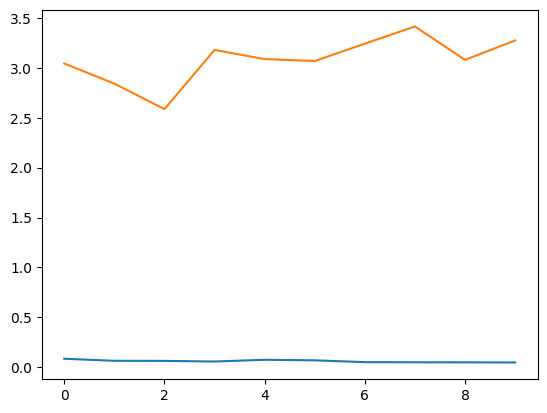

In [32]:
plt.plot(loss_train)
plt.plot(loss_test)